<a href="https://colab.research.google.com/github/NaraDaibes/Metabolic_syndrom_prediction/blob/Predictions-Of-Product-Sales/MetabolicSyndrom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# imports
import  pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split,  GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

In [ ]:
# file uploader
fpath='/content/drive/MyDrive/Metabolic  Syndrome (1).csv'
df=pd.read_csv(fpath)
df.head()

,seqn,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
0,62161,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,No MetSyn
1,62164,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,No MetSyn
2,62169,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,No MetSyn
3,62172,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,No MetSyn
4,62177,51,Male,Married,NaN,Asian,81.1,20.1,0,8.13,5.0,95,43,126,No MetSyn


# Cleaning

In [ ]:
df.shape

(2401, 15)

In [ ]:
df.describe()

,seqn,Age,Income,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides
count,2401.000000,2401.000000,2284.000000,2316.000000,2375.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000
mean,67030.674302,48.691795,4005.253940,98.307254,28.702189,0.154102,43.626131,5.489046,108.247813,53.369429,128.125364
std,2823.565114,17.632852,2954.032186,16.252634,6.662242,0.422780,258.272829,1.439358,34.820657,15.185537,95.322477
min,62161.000000,20.000000,300.000000,56.200000,13.400000,0.000000,1.400000,1.800000,39.000000,14.000000,26.000000
25%,64591.000000,34.000000,1600.000000,86.675000,24.000000,0.000000,4.450000,4.500000,92.000000,43.000000,75.000000
50%,67059.000000,48.000000,2500.000000,97.000000,27.700000,0.000000,7.070000,5.400000,99.000000,51.000000,103.000000
75%,69495.000000,63.000000,6200.000000,107.625000,32.100000,0.000000,13.690000,6.400000,110.000000,62.000000,150.000000
max,71915.000000,80.000000,9000.000000,176.000000,68.700000,2.000000,5928.000000,11.300000,382.000000,156.000000,1562.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2401 entries, 0 to 2400
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   seqn               2401 non-null   int64  
 1   Age                2401 non-null   int64  
 2   Sex                2401 non-null   object 
 3   Marital            2193 non-null   object 
 4   Income             2284 non-null   float64
 5   Race               2401 non-null   object 
 6   WaistCirc          2316 non-null   float64
 7   BMI                2375 non-null   float64
 8   Albuminuria        2401 non-null   int64  
 9   UrAlbCr            2401 non-null   float64
 10  UricAcid           2401 non-null   float64
 11  BloodGlucose       2401 non-null   int64  
 12  HDL                2401 non-null   int64  
 13  Triglycerides      2401 non-null   int64  
 14  MetabolicSyndrome  2401 non-null   object 
dtypes: float64(5), int64(6), object(4)
memory usage: 281.5+ KB


In [ ]:
df.isna().sum()

,0
seqn,0
Age,0
Sex,0
Marital,208
Income,117
Race,0
WaistCirc,85
BMI,26
Albuminuria,0
UrAlbCr,0


In [ ]:
over=df[df['Age']>120]
over
df['Sex'].value_counts()
df['Marital'].value_counts()
df['Race'].value_counts()
false=df[df['WaistCirc']>200]
false
df['Albuminuria'].value_counts()
over1=df[(df['BloodGlucose']<20) | (df['BloodGlucose']>1000)]
over1


,seqn,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome


In [ ]:
df['MetabolicSyndrome'].value_counts(normalize=True)

,proportion
MetabolicSyndrome,
No MetSyn,0.657643
MetSyn,0.342357


# Exploratory Visualization

*  We can notice from the graph below a high positively correlation between the waist circumference and the BMI.

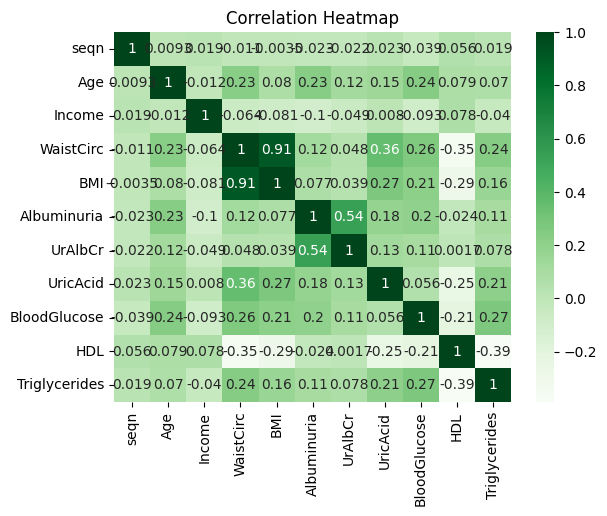

In [ ]:
corr=df.corr(numeric_only=True)
ax=sns.heatmap(corr,cmap='Greens', annot=True)
ax.set_title('Correlation Heatmap')
plt.show()

* The barplot below illustrates the variation in triglyceride levels across Sex and grouped by different racial groups.

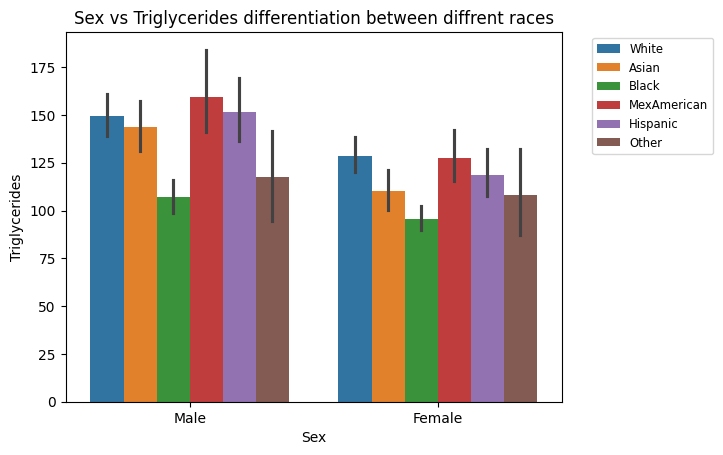

In [ ]:
ax=sns.barplot(data=df,x='Sex',y='Triglycerides', hue='Race')
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left', fontsize='small')
# title
plt.title('Sex vs Triglycerides differentiation between diffrent races')
plt.show()

* The boxplot shows the trigleceride levels across marital status grouped by sex.

<Axes: xlabel='Marital', ylabel='Triglycerides'>

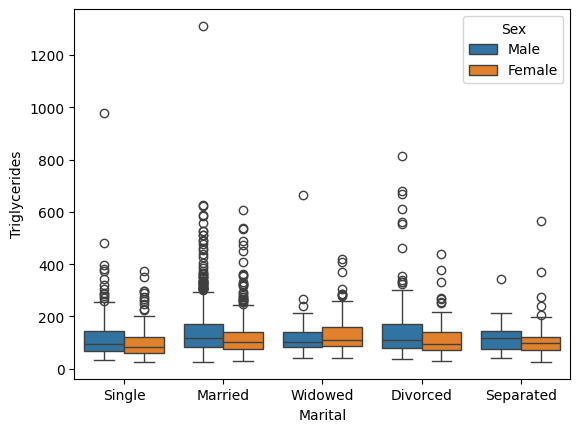

In [ ]:
sns.boxplot(data=df, x='Marital', y='Triglycerides', hue='Sex')

# Preprocessing

In [ ]:
# train test split
X= df.drop(columns=['MetabolicSyndrome', 'seqn'])
y=df['MetabolicSyndrome'].replace(['No MetSyn','MetSyn'],[1,0])

X_train,X_test,y_train,y_test= train_test_split(X,y,random_state=42)

/tmp/ipykernel_345/2632500343.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y=df['MetabolicSyndrome'].replace(['No MetSyn','MetSyn'],[1,0])


In [ ]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict



def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

In [ ]:
# column transformer
# numeric features
num_col=X_train.select_dtypes('number').columns
impute_median=SimpleImputer(strategy='median')
scaler=StandardScaler()
num_pipe=make_pipeline(impute_median,scaler)
num_tuple=('numeric', num_pipe,num_col)

# CATEGORICAL
cat_col=X_train.select_dtypes('object').columns
impute_Na=SimpleImputer(strategy='constant',fill_value='NA')
ohe_encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
cat_pipe=make_pipeline(impute_Na,ohe_encoder)
cat_tuple=('categorical',cat_pipe,cat_col)


# column transformer
col_transformer=ColumnTransformer([num_tuple,cat_tuple],remainder='drop' )
col_transformer.fit(X_train)
x_train_transformed=col_transformer.transform(X_train)
x_test_transformed=col_transformer.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE,SMOTENC
smote = SMOTE()
X_train_sm, y_train_sm = smote.fit_resample(x_train_transformed, y_train)
y_train_sm.value_counts()

,count
MetabolicSyndrome,
0,1182
1,1182


# KNN

In [ ]:
# Create a KNeighborsClassifier to be used with already transformed and oversampled data
knn = KNeighborsClassifier()
knn.fit(X_train_sm, y_train_sm)

KNeighborsClassifier()

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      1182
           1       0.95      0.84      0.89      1182

    accuracy                           0.90      2364
   macro avg       0.90      0.90      0.89      2364
weighted avg       0.90      0.90      0.89      2364



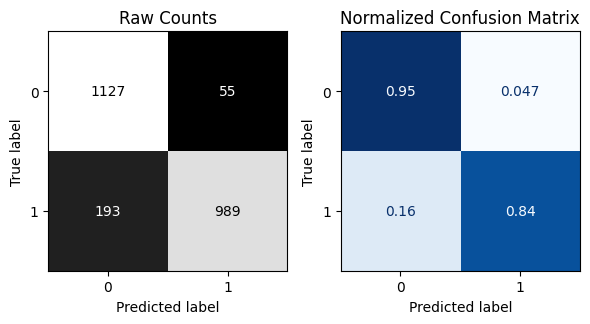


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.65      0.80      0.71       204
           1       0.88      0.78      0.83       397

    accuracy                           0.78       601
   macro avg       0.76      0.79      0.77       601
weighted avg       0.80      0.78      0.79       601



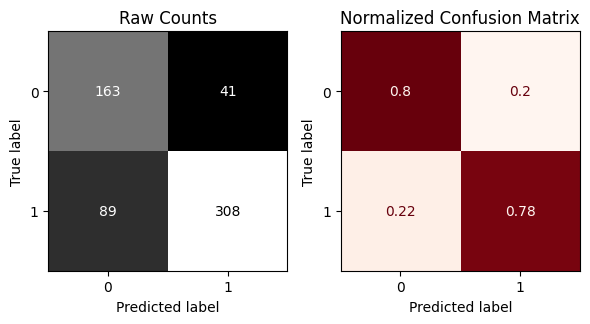

In [ ]:
evaluate_classification(knn,X_train_sm,y_train_sm,x_test_transformed,y_test)

In [ ]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [ ]:
param_grid={'n_neighbors':list(range(1,50,2)),
"algorithm":['auto', 'ball_tree', 'kd_tree', 'brute']}

In [ ]:
gridsearch=GridSearchCV(knn,param_grid=param_grid,cv=5,n_jobs=-1,verbose=1,scoring='recall_macro')
gridsearch.fit(X_train_sm,y_train_sm)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21,
                                         23, 25, 27, 29, 31, 33, 35, 37, 39, 41,
                                         43, 45, 47, 49]},
             scoring='recall_macro', verbose=1)

In [ ]:
gridsearch_best=gridsearch.best_params_
gridsearch_best

{'algorithm': 'auto', 'n_neighbors': 1}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1182
           1       1.00      1.00      1.00      1182

    accuracy                           1.00      2364
   macro avg       1.00      1.00      1.00      2364
weighted avg       1.00      1.00      1.00      2364



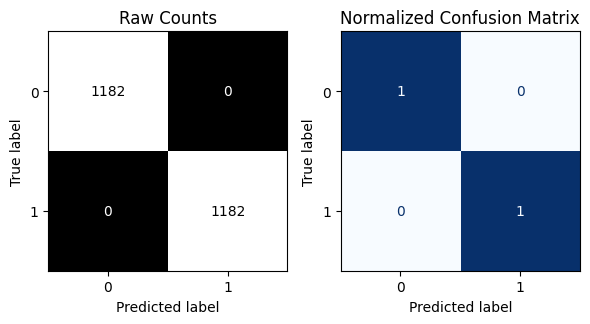


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.66      0.67      0.67       204
           1       0.83      0.82      0.83       397

    accuracy                           0.77       601
   macro avg       0.75      0.75      0.75       601
weighted avg       0.77      0.77      0.77       601



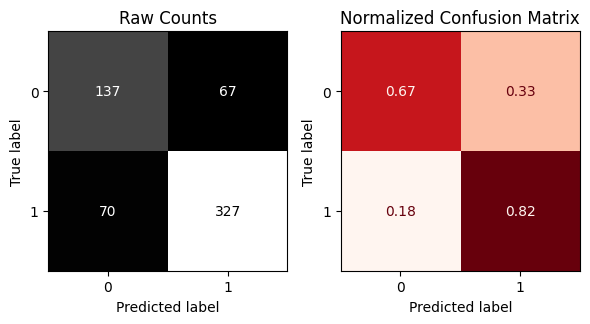

In [ ]:
evaluate_classification(gridsearch.best_estimator_, X_train_sm, y_train_sm, x_test_transformed, y_test)

# **permutation_importance**

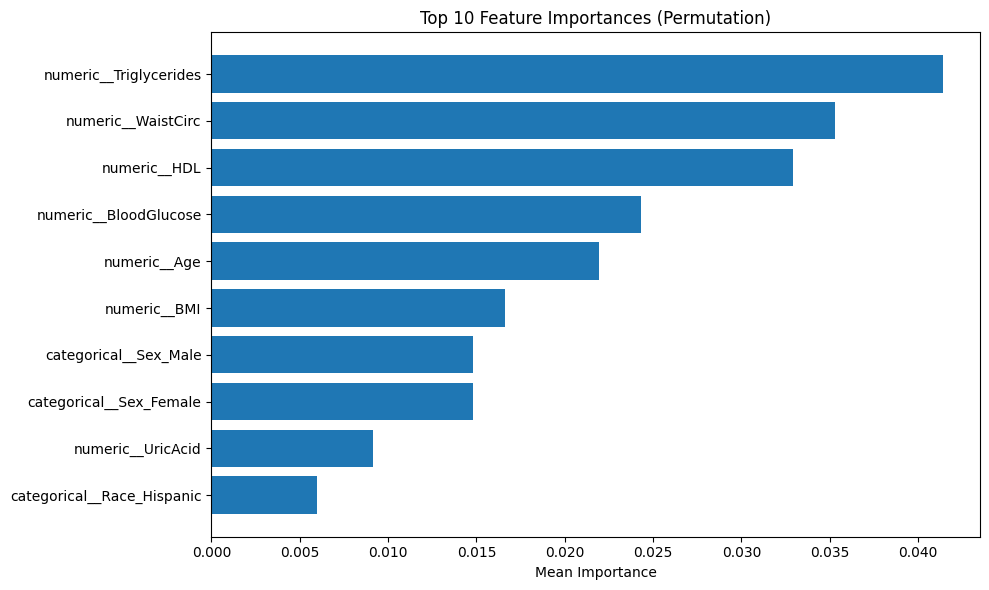

In [ ]:
from sklearn.inspection import permutation_importance

# Use the transformed test data (x_test_transformed) instead of the original X_test
result = permutation_importance(knn, x_test_transformed, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Correctly get feature names from the fitted ColumnTransformer
feature_names = col_transformer.get_feature_names_out()

importances = result.importances_mean
indices = np.argsort(importances)[::-1]  # Sort in descending order


## can make the mean importances into a series
permutation_importances = pd.Series(result['importances_mean'],index=feature_names,
                           name = 'permutation importance')
permutation_importances = permutation_importances.sort_values(ascending=False)
permutation_importances

top_n = 10
top_features = permutation_importances.head(top_n)
plt.figure(figsize=(10,6))
plt.barh(top_features.index[::-1], top_features.values[::-1], align='center')
plt.title("Top 10 Feature Importances (Permutation)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

In [ ]:
## can make the mean importances into a series
permutation_importances = pd.Series(result['importances_mean'],index=feature_names,
                           name = 'permutation importance')
permutation_importances = permutation_importances.sort_values(ascending=False)
permutation_importances

,permutation importance
numeric__Triglycerides,0.041431
numeric__WaistCirc,0.035275
numeric__HDL,0.032945
numeric__BloodGlucose,0.024293
numeric__Age,0.021963
numeric__BMI,0.016639
categorical__Sex_Male,0.014809
categorical__Sex_Female,0.014809
numeric__UricAcid,0.009151
categorical__Race_Hispanic,0.005990


<Axes: xlabel='MetabolicSyndrome', ylabel='Triglycerides'>

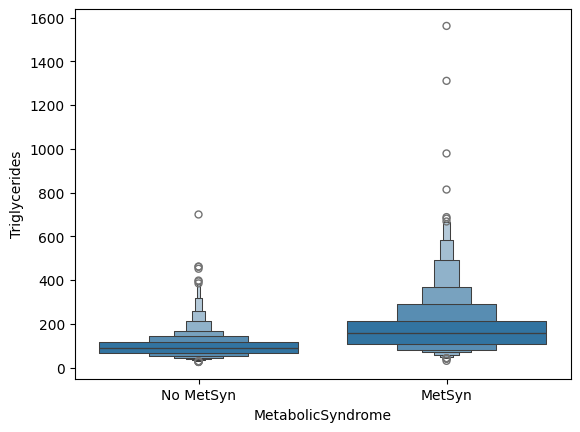

In [ ]:
sns.boxenplot(data=df,x='MetabolicSyndrome',y='Triglycerides')

<Axes: xlabel='MetabolicSyndrome', ylabel='BloodGlucose'>

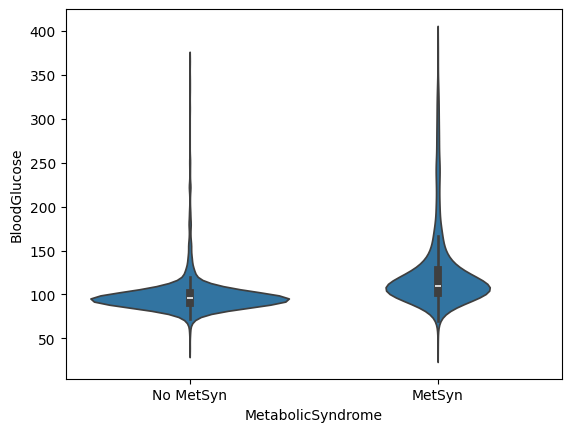

In [ ]:
sns.violinplot(data=df,x='MetabolicSyndrome',y='BloodGlucose')

# **Feature engeneering**

In [ ]:
from sklearn.decomposition import PCA

# Instantiate & fit data using PCA
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_sm)
X_test_pca = pca.transform(x_test_transformed)
#ARRAY
print(X_train_pca[:5])

[[ 1.05245279 -1.07345424 -0.51249038]
 [-1.80599723  0.36452723 -0.32052968]
 [-2.20211559 -0.0350661   0.65251067]
 [-1.13863222 -0.50495538 -0.33632027]
 [-1.05137805 -0.40060028  2.03747769]]


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1182
           1       0.81      0.81      0.81      1182

    accuracy                           0.81      2364
   macro avg       0.81      0.81      0.81      2364
weighted avg       0.81      0.81      0.81      2364



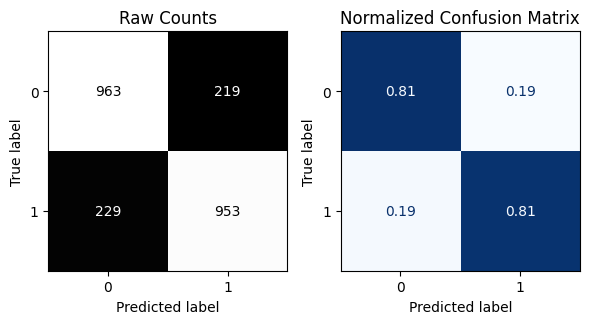


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.64      0.75      0.69       204
           1       0.86      0.79      0.82       397

    accuracy                           0.77       601
   macro avg       0.75      0.77      0.76       601
weighted avg       0.79      0.77      0.78       601



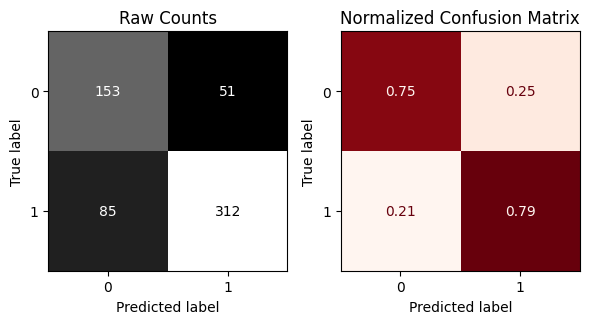

Training time was: 0:00:00.010155


In [ ]:
import datetime as dt

# Record the start time
start = dt.datetime.now()

clf = LogisticRegression(random_state=42)
clf.fit(X_train_pca, y_train_sm)

# Record the end time and calc duration
end = dt.datetime.now()
dur_pca = end-start

evaluate_classification(clf, X_train_pca,y_train_sm, X_test_pca, y_test)
print(f'Training time was: {dur_pca}')

In [ ]:
# Initialize and fit PCA
pca = PCA()
pca.fit(X_train_sm, y_train)

PCA()

In [ ]:
# Determine how much variance is explained by each PC
explained = pd.Series(pca.explained_variance_ratio_, name='Explained Variance Ratio')
explained

,Explained Variance Ratio
0,2.338484e-01
1,1.382254e-01
2,1.046686e-01
3,9.520816e-02
4,8.534332e-02
5,7.195561e-02
6,6.028277e-02
7,4.235917e-02
8,3.609250e-02
9,2.667840e-02


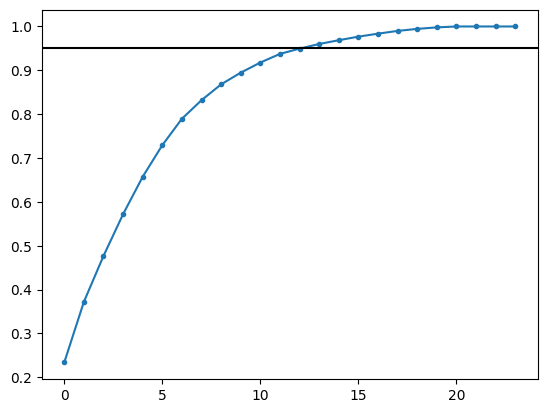

In [ ]:
# plot the cumulative sum of the percentage of explained variance for each component and those before it.
ax = explained.cumsum().plot(marker='.')
# add a line to mark .9 (or 90%) variance explained
ax.axhline(.95, color='k');

In [ ]:
# Define PCA to address 95% of the variance
pca95 = PCA(n_components=.95)
# fit and transform on training data
X_train_pca95 = pca95.fit_transform(X_train_sm)
# transform test data
X_test_pca95 = pca95.transform(x_test_transformed)
# obtain the number of PCs used
pca95.n_components_

np.int64(14)

* Timing when 95% of Variance is Explained with PCSs

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1182
           1       0.94      0.85      0.89      1182

    accuracy                           0.90      2364
   macro avg       0.90      0.90      0.90      2364
weighted avg       0.90      0.90      0.90      2364



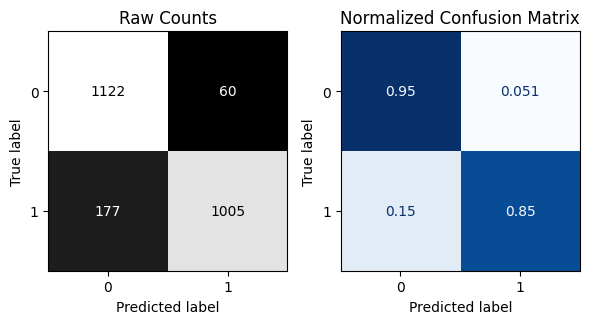


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.66      0.80      0.73       204
           1       0.89      0.79      0.83       397

    accuracy                           0.79       601
   macro avg       0.77      0.80      0.78       601
weighted avg       0.81      0.79      0.80       601



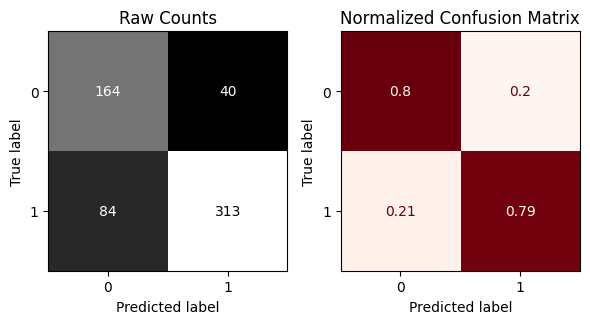

Training time was: 0:00:00.007754


In [ ]:
# Record the start time
start = dt.datetime.now()

clf = KNeighborsClassifier()
clf.fit(X_train_pca95, y_train_sm)

# Record the end time and calc duration
end = dt.datetime.now()
dur_pca_98 = end-start

evaluate_classification(clf, X_train_pca95,y_train_sm, X_test_pca95, y_test)
print(f'Training time was: {dur_pca_98}')

# Kmeans as a feature engeneering

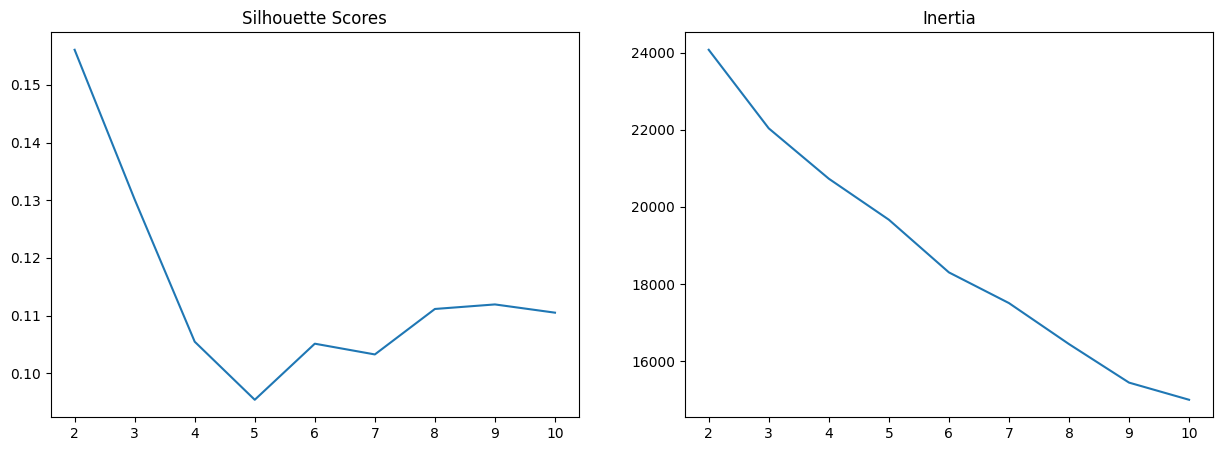

In [ ]:
# kmeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Transform the original feature data (X) using the pre-fitted ColumnTransformer
# X was defined as df.drop(columns=['Stage', 'ID'])
X_kmeans = col_transformer.transform(X)

ks = range(2,11)
sils = []
inertias = []
for k in ks:
  kmeans = KMeans(n_clusters=k, n_init = 'auto', random_state=42)
  kmeans.fit(X_kmeans) # Fit KMeans on the transformed numerical data
  sils.append(silhouette_score(X_kmeans, kmeans.labels_)) # Calculate silhouette score on the transformed data
  inertias.append(kmeans.inertia_)
#plot inertias and silhouette scores for each number of clusters.
fig, axes = plt.subplots(1,2, figsize=(15,5))
axes[0].plot(ks, sils)
axes[0].set_title('Silhouette Scores')
axes[0].set_xticks(ks)
axes[1].plot(ks, inertias)
axes[1].set_title('Inertia')
axes[1].set_xticks(ks);

In [ ]:
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)

# Fit KMeans on the SMOTEd training data (x_train_transformed already includes preprocessing)
kmeans.fit(X_train_sm)

# Get cluster labels for training and test data
train_clusters = kmeans.predict(X_train_sm)
test_clusters = kmeans.predict(x_test_transformed)

# Add cluster labels as new features to the existing transformed data
# Assuming X_train_sm and x_test_transformed are numpy arrays, concatenate the new feature
X_train_sm_clustered = np.hstack((X_train_sm, train_clusters.reshape(-1, 1)))
x_test_transformed_clustered = np.hstack((x_test_transformed, test_clusters.reshape(-1, 1)))

print("Shape of X_train_sm_clustered:", X_train_sm_clustered.shape)
print("Shape of x_test_transformed_clustered:", x_test_transformed_clustered.shape)

Shape of X_train_sm_clustered: (2364, 25)
Shape of x_test_transformed_clustered: (601, 25)


In [ ]:
clf_clustered = KNeighborsClassifier()
clf_clustered.fit(X_train_sm_clustered, y_train_sm)

KNeighborsClassifier()

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.96      0.90      1182
           1       0.95      0.84      0.89      1182

    accuracy                           0.90      2364
   macro avg       0.90      0.90      0.90      2364
weighted avg       0.90      0.90      0.90      2364



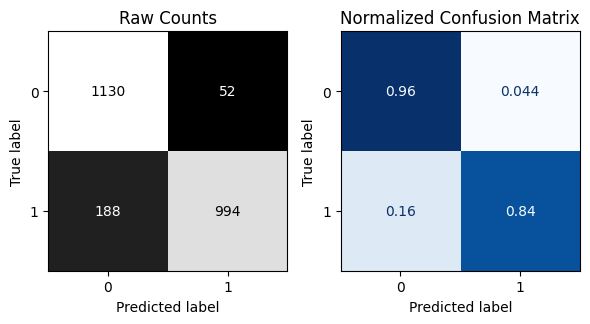


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.64      0.80      0.71       204
           1       0.88      0.77      0.82       397

    accuracy                           0.78       601
   macro avg       0.76      0.79      0.77       601
weighted avg       0.80      0.78      0.79       601



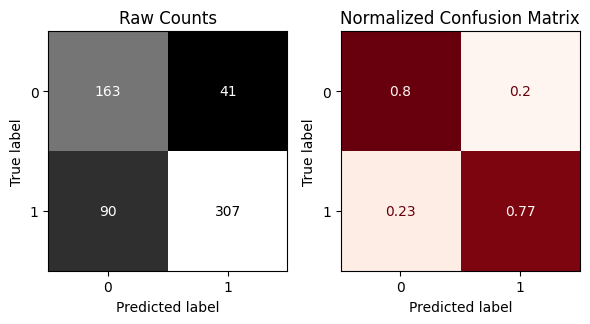

In [ ]:
# Evaluate the model with the clustered data
evaluate_classification(clf_clustered, X_train_sm_clustered, y_train_sm, x_test_transformed_clustered, y_test)

# **Feature selection**
|Wrapper|

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SequentialFeatureSelector

lg=KNeighborsClassifier()
# Instantiate the SequentialFeatureSelector
sk_sfs = SequentialFeatureSelector(clf_clustered, n_features_to_select=15,
                                direction = 'forward', cv=2,
                                 n_jobs=-1)
sk_sfs.fit(X_train_sm_clustered,y_train_sm)

SequentialFeatureSelector(cv=2, estimator=KNeighborsClassifier(),
                          n_features_to_select=15, n_jobs=-1)

In [ ]:
features_to_keep = sk_sfs.support_
# Only include the features selected
X_train_15 = X_train_sm_clustered[:,features_to_keep]
X_test_15 = x_test_transformed_clustered[:,features_to_keep]
X_train_15.shape

(2364, 15)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1182
           1       0.93      0.88      0.91      1182

    accuracy                           0.91      2364
   macro avg       0.91      0.91      0.91      2364
weighted avg       0.91      0.91      0.91      2364



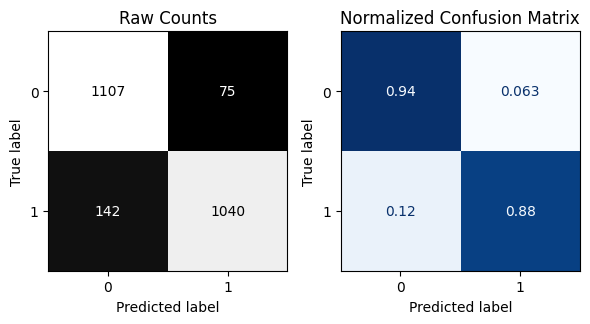


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.71      0.78      0.74       204
           1       0.88      0.84      0.86       397

    accuracy                           0.82       601
   macro avg       0.80      0.81      0.80       601
weighted avg       0.82      0.82      0.82       601



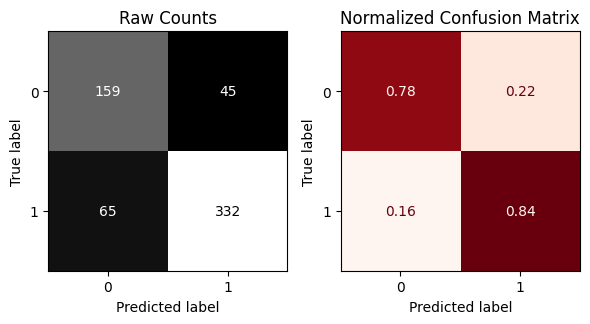

In [ ]:
lr_clf = KNeighborsClassifier()
# Fit on selected features
lr_clf.fit(X_train_15, y_train_sm)
# Evaluate with custom function
evaluate_classification(lr_clf, X_train_15, y_train_sm, X_test_15, y_test)

# Top 10 features

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(lr_clf, X_test_15, y_test, n_repeats=10, random_state=42, n_jobs=-1)

original_feature_names = list(col_transformer.get_feature_names_out())

all_feature_names_with_cluster = original_feature_names + ['cluster_feature']

feature_names = np.array(all_feature_names_with_cluster)[sk_sfs.support_]

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

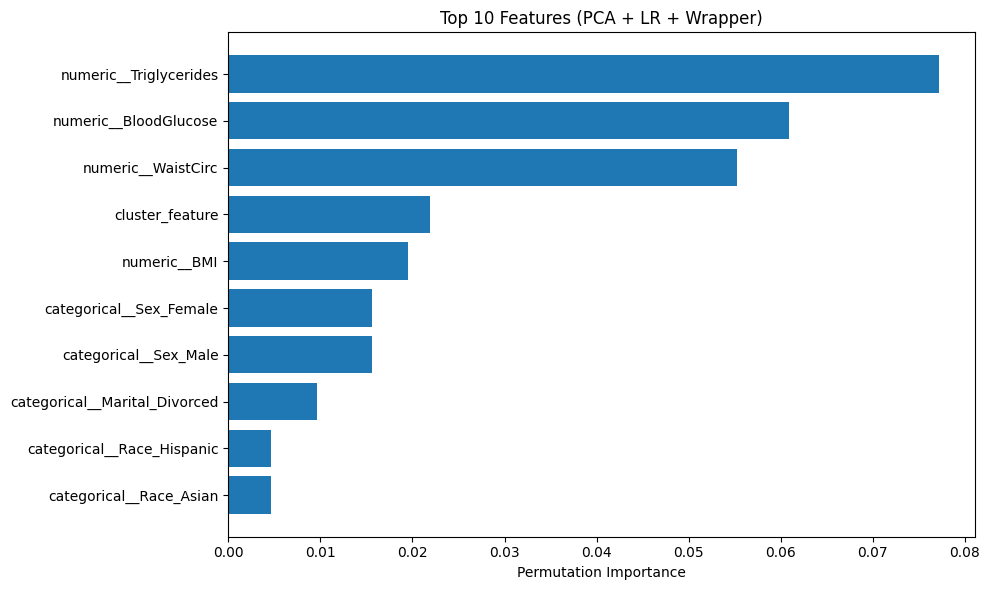

In [ ]:
import matplotlib.pyplot as plt

top_n = 10
top_features = [feature_names[i] for i in indices[:top_n]]
top_importances = importances[indices[:top_n]]

plt.figure(figsize=(10,6))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Permutation Importance")
plt.title("Top 10 Features (PCA + LR + Wrapper)")
plt.tight_layout()
plt.show()

In [ ]:
## can make the mean importances into a series
permutation_importances = pd.Series(result['importances_mean'],index=feature_names,
                           name = 'permutation importance')
permutation_importances = permutation_importances.sort_values(ascending=False)
permutation_importances

,permutation importance
numeric__Triglycerides,0.077205
numeric__BloodGlucose,0.060899
numeric__WaistCirc,0.055241
cluster_feature,0.021963
numeric__BMI,0.019468
categorical__Sex_Male,0.015641
categorical__Sex_Female,0.015641
categorical__Marital_Divorced,0.009651
categorical__Race_Asian,0.004659
categorical__Race_Hispanic,0.004659


# **Deep Learning**

In [ ]:
#Keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras import metrics
from tensorflow.keras.layers import Dense, Dropout

#Sci-kit Learn
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):

    # Get the classification report
    report = classification_report(y_true, y_pred)
    ## Print header and report
    header = "-"*70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    ## CONFUSION MATRICES SUBPLOTS
    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # create a confusion matrix  of raw counts
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', values_format="d", colorbar=colorbar,
                ax = axes[0],);
    axes[0].set_title("Raw Counts")

    # create a confusion matrix with the test data
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, values_format=".2f", colorbar=colorbar,
                ax = axes[1]);
    axes[1].set_title("Normalized Confusion Matrix")

    # Adjust layout and show figure
    fig.tight_layout()
    plt.show()

    # Return dictionary of classification_report
    if output_dict==True:
        report_dict = classification_report(y_true, y_pred, output_dict=True)
        return report_dict

In [ ]:
# Custom function for plotting each metric
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()

    return fig, axes

In [ ]:
# define input shape
input_shape = x_test_transformed.shape[1]
input_shape

24

In [ ]:
# Build binary classification model within function
def build_model():
    # Instantiate Model
    model = Sequential()

    # First hidden layer
    model.add(Dense(32, # How many neurons you have in your first hidden layer
                input_dim =input_shape, # What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
    model.add(Dense(8, activation = 'relu'))
    model.add(Dropout(.5))
    model.add(Dense(1, activation = 'sigmoid'))

    # Compile Model
    model.compile(loss = 'bce', optimizer = 'adam',
             metrics=['accuracy', metrics.Precision(), metrics.Recall()])
    return model

In [ ]:
# Call our build function to build model
clf_model = build_model()

# Get model summary
clf_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,073 (4.19 KB)

 Trainable params: 1,073 (4.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)
history = clf_model.fit(X_train_sm, y_train_sm,
                        validation_data=(x_test_transformed, y_test),
                        epochs=100,
                        verbose=0, callbacks=[early_stop])

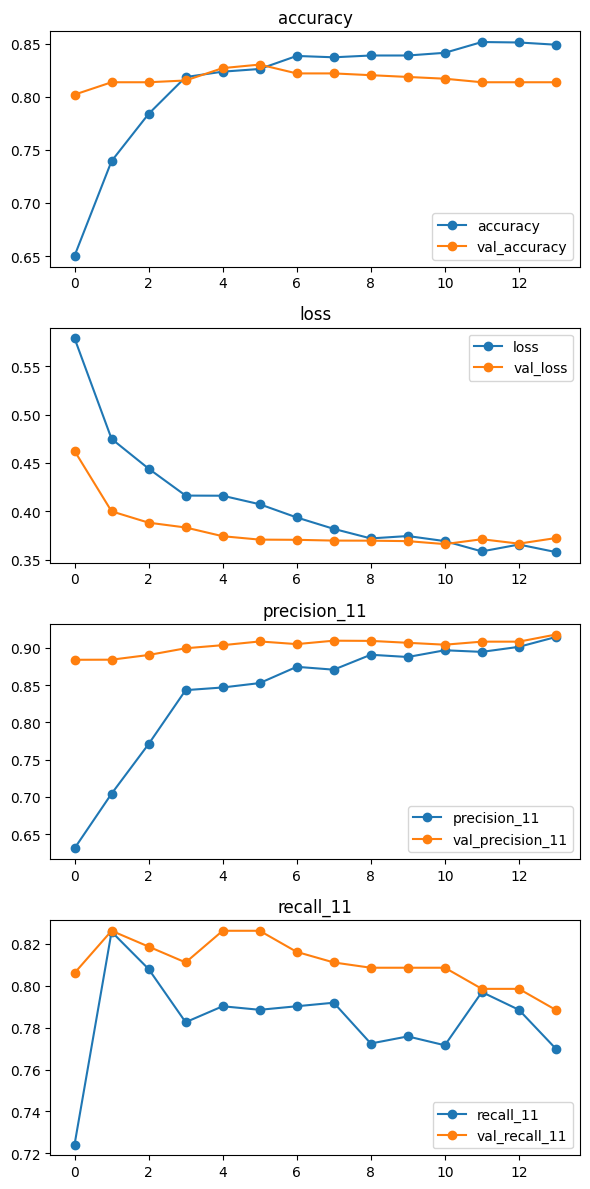

In [ ]:
# plot learning history
plot_history(history);

In [ ]:
# make predictions
y_pred_test = clf_model.predict(x_test_transformed)
y_pred_test[:5]

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[0.5109862 ],
       [0.2647587 ],
       [0.38666213],
       [0.4907315 ],
       [0.00861688]], dtype=float32)

In [ ]:
# round the predictions
y_pred_test = np.round(y_pred_test)
y_pred_test[:5]

array([[1.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32)

              precision    recall  f1-score   support

           0       0.68      0.86      0.76       204
           1       0.92      0.79      0.85       397

    accuracy                           0.81       601
   macro avg       0.80      0.83      0.80       601
weighted avg       0.84      0.81      0.82       601



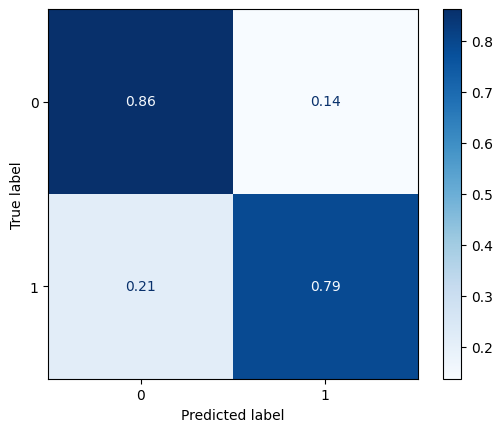

In [ ]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print(classification_report(y_test, y_pred_test))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues',
                                       normalize='true');